In [5]:
import matplotlib.pyplot as plt
import json
from pathlib import Path

In [6]:
result_dir = Path("./results")

results = {}

for result_file in result_dir.glob("*.json"):
    concurrency = int(result_file.stem.split("_")[-1])

    with open(result_file, "r") as f:
        result = json.load(f)
        throughput_per_gpu = result["total_token_throughput"] / 4
        interactivity = result["output_throughput"] / concurrency

        results[concurrency] = {
            "throughput_per_gpu": throughput_per_gpu,
            "interactivity": interactivity,
        }


In [7]:
results

{512: {'throughput_per_gpu': 1720.6264626086504,
  'interactivity': 6.721197119565041},
 64: {'throughput_per_gpu': 1026.5388746084084,
  'interactivity': 32.07933983151276},
 4096: {'throughput_per_gpu': 1040.945236454489,
  'interactivity': 0.5082740412375435},
 1024: {'throughput_per_gpu': 1080.0024808268142,
  'interactivity': 2.1093798453648716},
 128: {'throughput_per_gpu': 721.9657027628148,
  'interactivity': 11.28071410566898},
 2048: {'throughput_per_gpu': 1036.8673218419888,
  'interactivity': 1.0125657439863172},
 256: {'throughput_per_gpu': 1493.5528811643278,
  'interactivity': 11.668381884096311}}

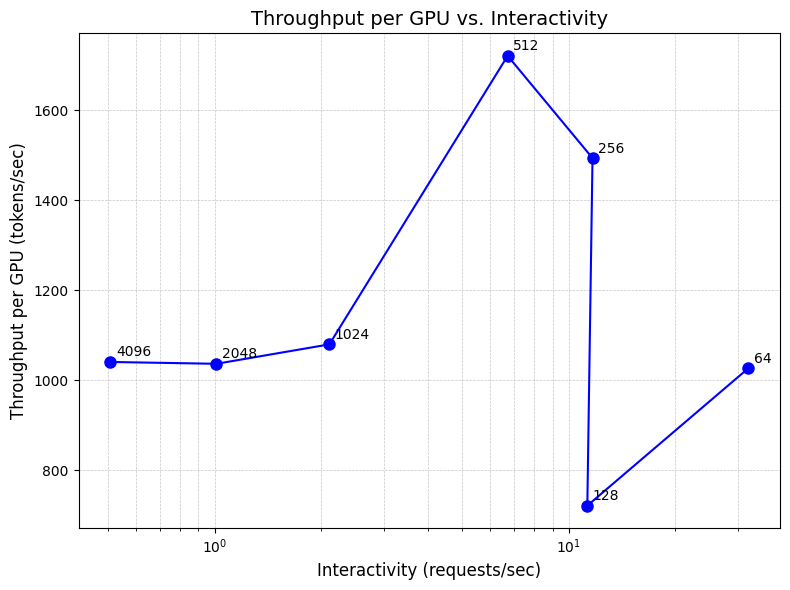

In [10]:
import numpy as np

sorted_keys = sorted(results.keys())
interactivities = [results[k]['interactivity'] for k in sorted_keys]
throughputs = [results[k]['throughput_per_gpu'] for k in sorted_keys]

plt.figure(figsize=(8,6))
plt.plot(interactivities, throughputs, '-o', color='blue', markersize=8)
plt.xscale('log')
plt.xlabel('Interactivity (requests/sec)', fontsize=12)
plt.ylabel('Throughput per GPU (tokens/sec)', fontsize=12)
plt.title('Throughput per GPU vs. Interactivity', fontsize=14)
plt.grid(True, which="both", ls="--", linewidth=0.5, alpha=0.7)
for k, v in results.items():
    plt.annotate(str(k), (v['interactivity'], v['throughput_per_gpu']),
                 textcoords="offset points", xytext=(4,4), ha='left', fontsize=10)
plt.tight_layout()
plt.show()